In [ ]:
#Activity log
#Bolortulga Seded
#27/02/2026
#Week 3 - Task 1: Outlier detection & removal (IQR); 
                #MinMaxScaler & StandardScaler normalisation — Diabetes.csv,

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes (1).csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome    

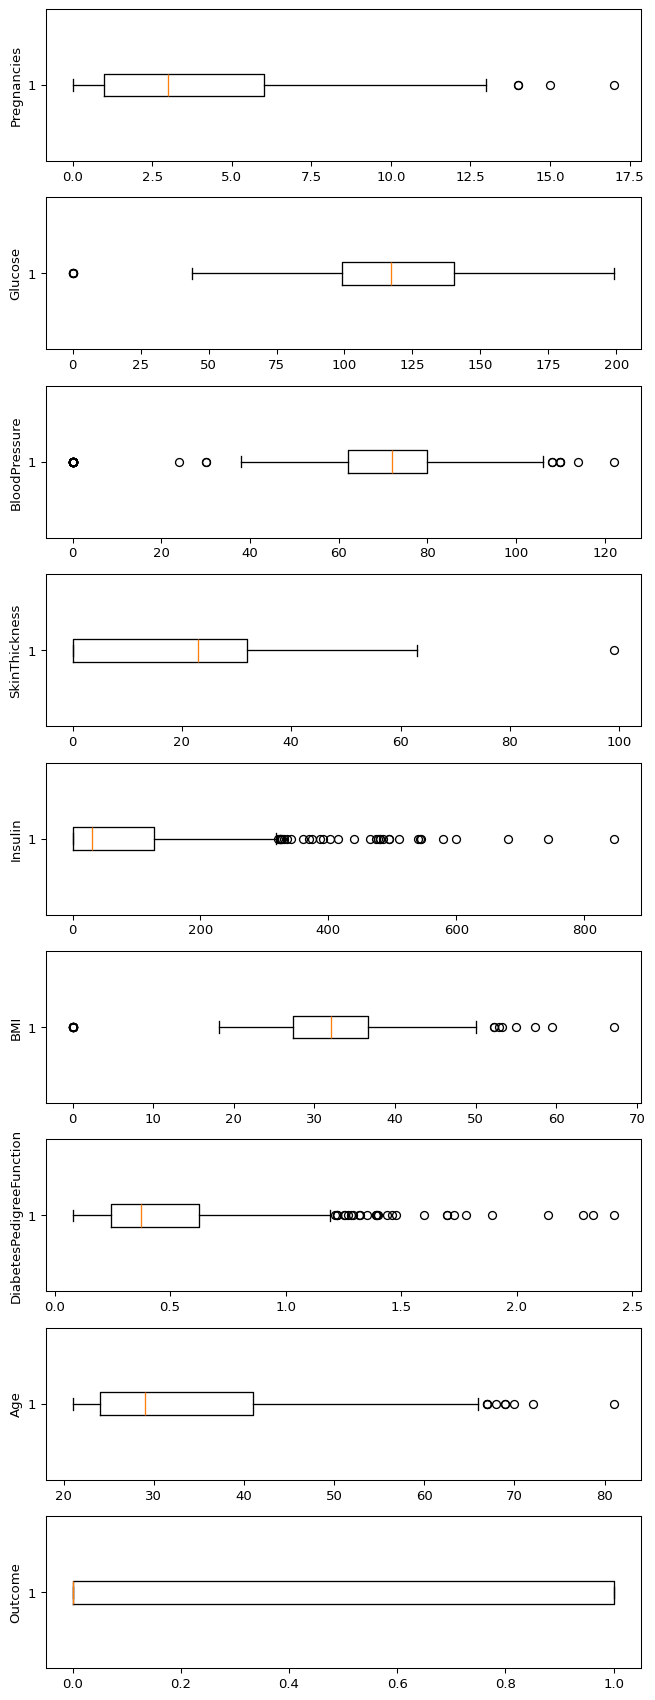

In [5]:
df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [6]:
q1, q3 = np.percentile(df['Insulin'], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Lower Bound: {lower}, Upper Bound {upper}")
clean_df = df[(df['Insulin'] >= lower) & (df['Insulin'] <= upper)]

Q1: 0.0, Q3: 127.25, IQR: 127.25
Lower Bound: -190.875, Upper Bound 318.125


In [7]:
print("\nOriginal shape:", df.shape)
print("Cleaned shape: ", clean_df.shape)
print("Rows removed: ", df.shape[0] - clean_df.shape[0])


Original shape: (768, 9)
Cleaned shape:  (734, 9)
Rows removed:  34


In [8]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [9]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
print("\nAfter MinMaxScaler (first 5 rows):")
print(X_normalized[:5])

scaler2 = StandardScaler()
X_standardized = scaler2.fit_transform(X)
print("\nAfter StandardScaler (first 5 rows):")
print(X_standardized[:5])


After MinMaxScaler (first 5 rows):
[[0.35294118 0.74371859 0.59016393 0.35353535 0.         0.50074516
  0.23441503 0.48333333]
 [0.05882353 0.42713568 0.54098361 0.29292929 0.         0.39642325
  0.11656704 0.16666667]
 [0.47058824 0.91959799 0.52459016 0.         0.         0.34724292
  0.25362938 0.18333333]
 [0.05882353 0.44723618 0.54098361 0.23232323 0.11111111 0.41877794
  0.03800171 0.        ]
 [0.         0.68844221 0.32786885 0.35353535 0.19858156 0.64232489
  0.94363792 0.2       ]]

After StandardScaler (first 5 rows):
[[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.765